In [1]:
# Equivalent en Python amb scipy.signal
# Identificar el model, el diagrama de Bode, i implementar PI
# J.A. Mayugo, UdG, 2023 - 2026

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
# -------------------------------------------------------------------------
# Propietats del sistema
# -------------------------------------------------------------------------

n_N = 5420      # rpm, velocitat nominal del motor

U = 48          # V, input 'bump test'
A = 2.20        # rad/sV, guany del sistema
B = 12.5e-3     # s, constant de temps del sistema

omega_n_v = 60    # rad/s, freqüència natural desitjada per al sistema controlat (velocitat)
omega_n_p = 60    # rad/s, freqüència natural desitjada per al sistema controlat (posició)
zeta = 0.90     # -, esmorteiment desitjat per alS sistemes controlats

i_red = 25;     # -, relació de reducció
pitch = 5e-3;   # m/volta; pas del cargol

rG = 60e-3;     # m, radi politges grans
rP = 40e-3;     # m, radi politges petites
rR = 15e-3;     # m, radi politges reenviament

iC = 2*np.pi/pitch   # voltes/m, conversió de velocitat angular a lineal cargol potència
iT = i_red*rG/rP*iC  # -, relació de transmissió total

print("\nRelacions de transmissió:")
print(f"iC = {iC:.4f}")
print(f"iT = {iT:.4f}")

t_final = 0.18   # s, temps final de simulació
t_ = np.arange(0, t_final, 0.0001)   # resposta temporal


Relacions de transmissió:
iC = 1256.6371
iT = 47123.8898


In [3]:
# -------------------------------------------------------------------------
# INTERPRETACIÓ DEL MODEL DE 1r ORDRE
# -------------------------------------------------------------------------

tau = B
K = A

tau_pos = 5 * tau  # s, constant de temps desitjada pel llaç extern de posició, major que tau

# Funció de transferència del motor:
#               K
# Gm(s) = -------------
#          tau*s + 1

num_Gm = [K]
den_Gm = [tau, 1]

G_m = signal.TransferFunction(num_Gm, den_Gm)

# Funció de transferència del motor en posició:
#               K
# Gp(s) = -------------
#         tau*s^2 + s

num_Gp = num_Gm
den_Gp = np.polymul(den_Gm, [1, 0])  # afegeix integrador 1/s

G_p = signal.TransferFunction(num_Gp, den_Gp)

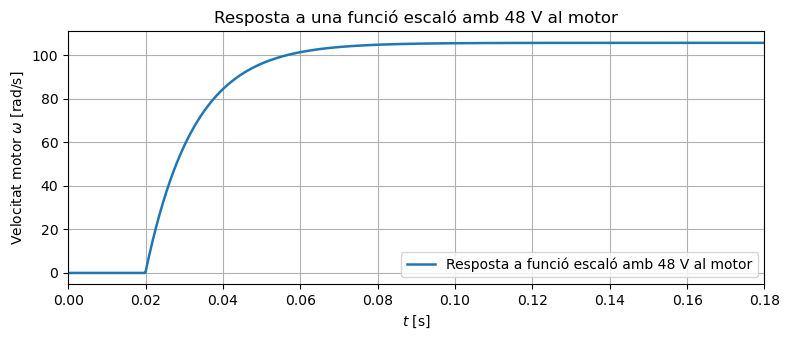

In [4]:
# -------------------------------------------------------------------------
# Resposta en llaç obert a una funció escaló
# -------------------------------------------------------------------------

U_ = U * (t_ >= 0.02)

t_out, omg, x = signal.lsim(G_m, U_, t_)

H_ol = plt.figure(figsize=(8, 3.5))
#plt.plot(t_out, U_, '--', linewidth=1.2)
plt.plot(t_out, omg, linewidth=1.8, label=rf'Resposta a funció escaló amb {U} V al motor')
plt.xlim(0, t_final)
plt.grid(True)
plt.title(f"Resposta a una funció escaló amb {U} V al motor")
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"Velocitat motor $\omega$ [rad/s]")
plt.legend()
plt.tight_layout()
#plt.savefig('CSM_assaig_SOL1.pdf', bbox_inches='tight')


Pols del sistema en llaç obert de G_m:
[-80.]

Pols del sistema en llaç obert de G_p:
[-80.   0.]


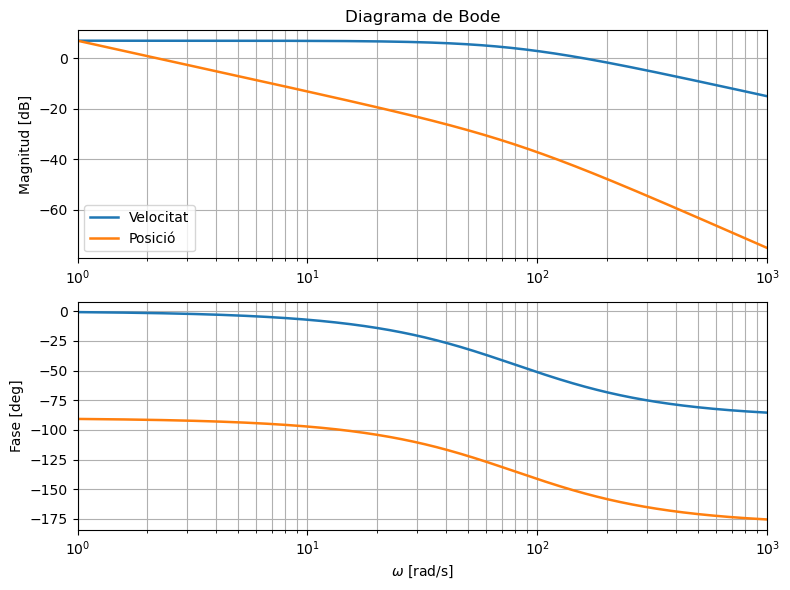

In [5]:
# -------------------------------------------------------------------------
# Diagrama de Bode
# -------------------------------------------------------------------------

w_ = np.logspace(0, 3, 1000)   # de 10^0 a 10^3 rad/s

w_m, mag_m, phase_m = signal.bode(G_m, w=w_)
w_p, mag_p, phase_p = signal.bode(G_p, w=w_)

H_bode = plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.semilogx(w_m, mag_m, linewidth=1.8, label='Velocitat')
plt.semilogx(w_p, mag_p, linewidth=1.8, label='Posició')
plt.xlim(10**0, 10**3)
plt.grid(True, which='both')
plt.ylabel("Magnitud [dB]")
plt.title("Diagrama de Bode")
plt.legend()

plt.subplot(2, 1, 2)
plt.semilogx(w_m, phase_m, linewidth=1.8)
plt.semilogx(w_p, phase_p, linewidth=1.8)
plt.xlim(10**0, 10**3)
plt.grid(True, which='both')

plt.xlabel(r"$\omega$ [rad/s]")
plt.ylabel("Fase [deg]")

plt.tight_layout()
#plt.savefig('CSM_assaig_SOL2.pdf', bbox_inches='tight')

# Pols del sistema

p = np.roots(den_Gm)
print("\nPols del sistema en llaç obert de G_m:")
print(p)

p = np.roots(den_Gp)
print("\nPols del sistema en llaç obert de G_p:")
print(p)


Guanys del controlador PI:
Kp = 0.1591
Ki = 20.4545

Pols del sistema en llaç tancat en velocitat:
[-54.+26.15339366j -54.-26.15339366j]


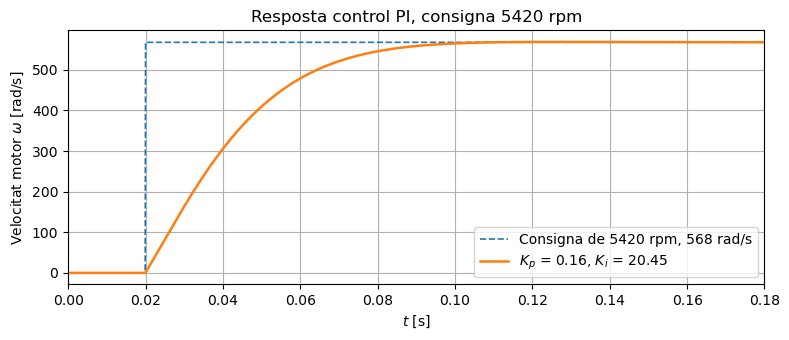

In [6]:
# -------------------------------------------------------------------------
# Control velocitat llaç tancat
# considerant un sistema de 2n ordre
# -------------------------------------------------------------------------

K1p = (2 * zeta * omega_n_v * tau - 1) / K
K1i = (omega_n_v**2 * tau) / K

print("\nGuanys del controlador PI:")
print(f"Kp = {K1p:.4f}")
print(f"Ki = {K1i:.4f}")

num_PI = [K1p, K1i]
den_PI = [1, 0]

num_ol = np.polymul(num_PI, num_Gm)
den_ol = np.polymul(den_PI, den_Gm)

den_cl = np.polyadd(den_ol, num_ol)
num_cl = num_ol

G_cl = signal.TransferFunction(num_cl, den_cl)

# Pols en llaç tancat

p_cl = np.roots(den_cl)
print("\nPols del sistema en llaç tancat en velocitat:")
print(p_cl)

# Resposta temporal llaç tancat

u = n_N    # rpm

# Conversió rpm -> rad/s
u_ = (u / 30) * np.pi * (t_ >= 0.02)

t_out, omg_cl, x = signal.lsim(G_cl, u_, t_)

H_cl = plt.figure(figsize=(8, 3.5))

plt.plot(t_out, u_, '--', linewidth=1.2)
plt.plot(t_out, omg_cl, linewidth=1.8)
plt.xlim(0, t_final)
plt.grid(True)
plt.title(f"Resposta control PI, consigna {u} rpm")
plt.xlabel(r"$t$ [s]")
plt.ylabel(r"Velocitat motor $\omega$ [rad/s]")
plt.legend(
    [rf"Consigna de {u} rpm, {u/30*np.pi:.0f} rad/s", 
     rf"$K_p$ = {K1p:.2f}, $K_i$ = {K1i:.2f}"], loc='lower right')

plt.tight_layout()
#plt.savefig('CSM_assaig_SOL3.pdf', bbox_inches='tight')


Guanys del controlador PD:
Kp = 20.4545
Kd = 0.1591

Pols del sistema en llaç tancat en posició:
[-54.+26.15339366j -54.-26.15339366j]


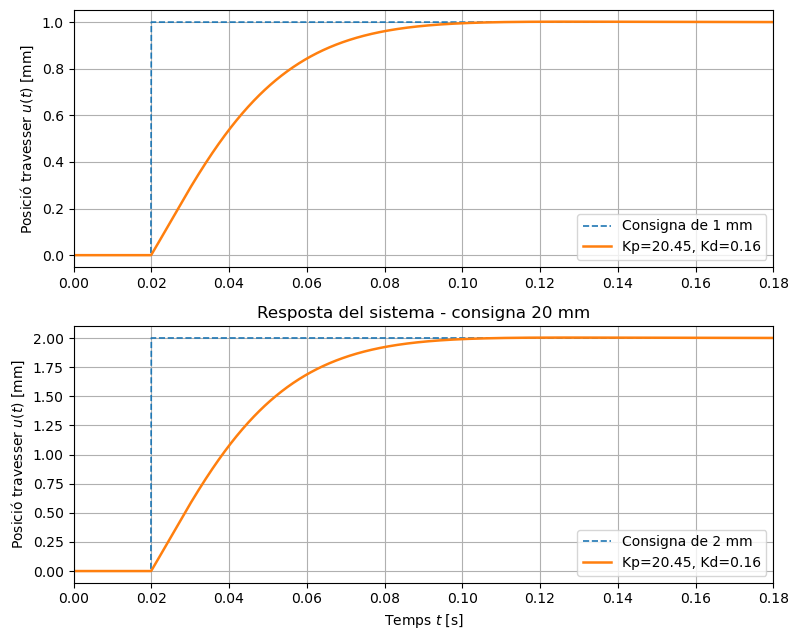

In [7]:
# -------------------------------------------------------------------------
# Control posició llaç tancat
# considerant un sistema de 2n ordre
# -------------------------------------------------------------------------

K2p = (omega_n_p**2 * tau) / K
K2d = (2 * zeta * omega_n_p * tau - 1) / K

print("\nGuanys del controlador PD:")
print(f"Kp = {K2p:.4f}")
print(f"Kd = {K2d:.4f}")

num_PD = [K2d, K2p]

num_ol_theta = np.polymul(num_PD, num_Gp)
den_ol_theta = den_Gp

den_cl_theta = np.polyadd(den_ol_theta, num_ol_theta)
num_cl_theta = num_ol_theta

G_cl_theta = signal.TransferFunction(num_cl_theta, den_cl_theta)

# Pols en llaç tancat

p_cl = np.roots(den_cl_theta)
print("\nPols del sistema en llaç tancat en posició:")
print(p_cl)

# Resposta temporal llaç tancat

# Consignes de posició del travesser (mm)
u1 = 1e-3   # 1 mm
u2 = 2e-3  # 2 mm

theta1_ = u1 * iT * (t_ >= 0.02)
theta2_ = u2 * iT * (t_ >= 0.02)

t_out, theta1_out, _ = signal.lsim(G_cl_theta, theta1_, t_)
t_out, theta2_out, _ = signal.lsim(G_cl_theta, theta2_, t_)

omega1_out = np.gradient(theta1_out, t_out)
omega2_out = np.gradient(theta2_out, t_out)

fig, ax = plt.subplots(2, 1, figsize=(8, 6.5))

ax[0].plot(t_, theta1_ / iT * 1e3, '--', linewidth=1.2)
ax[0].plot(t_, theta1_out / iT *1e3, linewidth=1.8)
ax[0].set_xlim(0, t_final)
ax[0].grid(True)
#ax[0].set_title("Resposta del sistema - consigna 2 mm")
ax[0].set_ylabel(r"Posició travesser $u(t)$ [mm]")

ax[0].legend([rf"Consigna de {u1*1e3:.0f} mm", 
              rf"Kp={K2p:.2f}, Kd={K2d:.2f}"], loc='lower right')

ax[1].plot(t_, theta2_ / iT * 1e3, '--', linewidth=1.2)
ax[1].plot(t_out, theta2_out / iT * 1e3, linewidth=1.8)
ax[1].set_xlim(0, t_final)
ax[1].grid(True)
ax[1].set_title("Resposta del sistema - consigna 20 mm")
ax[1].set_xlabel(r"Temps $t$ [s]")
ax[1].set_ylabel(r"Posició travesser $u(t)$ [mm]")

# ax1_v = ax[1].twinx()
# ax1_v.plot( t_out, omega2_out, ':', linewidth=1.6)
# ax1_v.set_ylabel(r"Velocitat $\omega(t)$ [rad/s]")

ax[1].legend(
    [rf"Consigna de {u2*1e3:.0f} mm", 
     rf"Kp={K2p:.2f}, Kd={K2d:.2f}", 
     rf"Velocitat $\omega(t)$ [rad/s]"],
     loc='lower right')

plt.tight_layout()
#plt.savefig('CSM_assaig_SOL4.pdf', bbox_inches='tight')

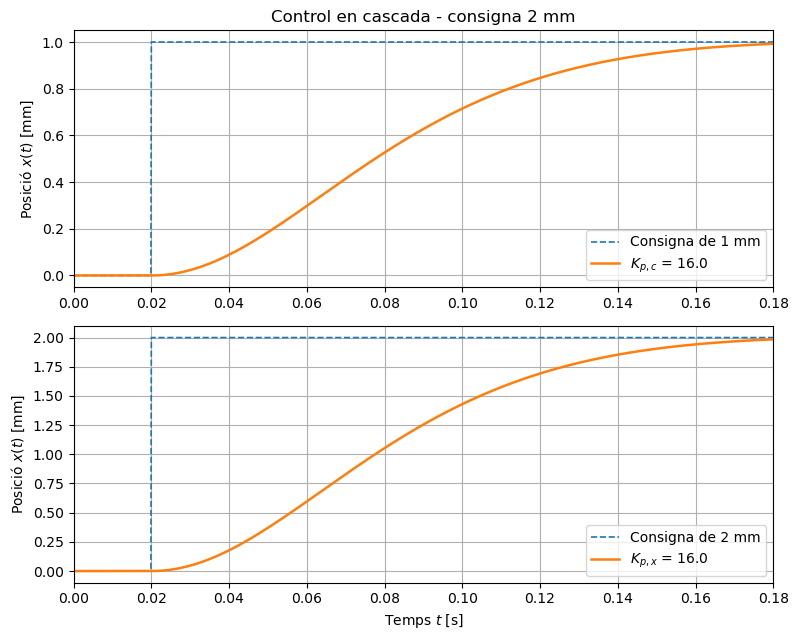

In [8]:
# -------------------------------------------------------------------------
# Control en doble llaç o control en cascada
# amb un controlador proporcional extern i un controlador PD intern
# -------------------------------------------------------------------------

# -------------------------------------------------------------------------
# Planta equivalent del llaç intern
#
# G_cl = omega / omega_ref
#
# Afegint integrador:
#
# theta / omega_ref
# -------------------------------------------------------------------------

num_theta_cascade = G_cl.num
den_theta_cascade = np.polymul(G_cl.den, [1, 0])

G_cascade = signal.TransferFunction(
    num_theta_cascade,
    den_theta_cascade
)

# Controlador proporcional extern

Kp_c =  1/tau_pos

num_Pc = [Kp_c]

num_ol_c = np.polymul(num_Pc, num_theta_cascade)
den_ol_c = den_theta_cascade

den_cl_c = np.polyadd(den_ol_c, num_ol_c)
num_cl_c = num_ol_c

G_cl_c = signal.TransferFunction(num_cl_c, den_cl_c)

# Resposta temporal llaç tancat control en cascada

theta1_ = u1 * iT * (t_ >= 0.02)
theta2_ = u2 * iT * (t_ >= 0.02)

t_out, theta1_out, _ = signal.lsim(G_cl_c, theta1_, t_)
t_out, theta2_out, _ = signal.lsim(G_cl_c, theta2_, t_)

omega1_out = np.gradient(theta1_out, t_out)
omega2_out = np.gradient(theta2_out, t_out)

fig, ax = plt.subplots(2, 1, figsize=(8, 6.5))

ax[0].plot(t_out, theta1_ / iT * 1e3, '--', linewidth=1.2)
ax[0].plot(t_out, theta1_out / iT * 1e3, linewidth=1.8)
ax[0].set_xlim(0, t_final)
ax[0].grid(True)
ax[0].set_title("Control en cascada - consigna 2 mm")
ax[0].set_ylabel(r"Posició $x(t)$ [mm]")

ax[0].legend(
    [rf"Consigna de {u1*1e3:.0f} mm", rf"$K_{{p,c}}$ = {Kp_c:.1f}"],
    loc='lower right')

ax[1].plot(t_out, theta2_ / iT * 1e3, '--', linewidth=1.2)
ax[1].plot(t_out, theta2_out / iT * 1e3, linewidth=1.8)
ax[1].set_xlim(0, t_final)
ax[1].grid(True)
#ax[1].set_title("Control en cascada - consigna 20 mm")
ax[1].set_xlabel(r"Temps $t$ [s]")
ax[1].set_ylabel(r"Posició $x(t)$ [mm]")

# ax1_v = ax[1].twinx()
# ax1_v.plot( t_out, omega2_out, ':', linewidth=1.6)
# ax1_v.set_ylabel(r"Velocitat $\omega(t)$ [rad/s]")

ax[1].legend(
    [rf"Consigna de {u2*1e3:.0f} mm", 
     rf"$K_{{p,x}}$ = {Kp_c:.1f}", 
     rf"Velocitat $\omega(t)$ [rad/s]"],
     loc='lower right')

plt.tight_layout()
#plt.savefig('CSM_assaig_SOL5.pdf', bbox_inches='tight')

plt.show()